In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# "C:\Users\umend\Downloads\loan_data.csv"

In [10]:
df = pd.read_csv("C:/Users/umend/Downloads/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [7]:
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [13]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [23]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [29]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred_log = log_model.predict(X_test)

y_pred_log[:10]

array([0, 0, 1, 0, 1, 0, 0, 1, 0, 1])

In [34]:
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.8901111111111111


In [35]:
precision_log = precision_score(y_test, y_pred_log)

print("Precision:", precision_log)

Precision: 0.766301512780386


In [36]:
recall_log = recall_score(y_test, y_pred_log)

print("Recall:", recall_log)

Recall: 0.7308457711442786


In [37]:
f1_log = f1_score(y_test, y_pred_log)

print("F1 Score:", f1_log)

F1 Score: 0.7481538069773364


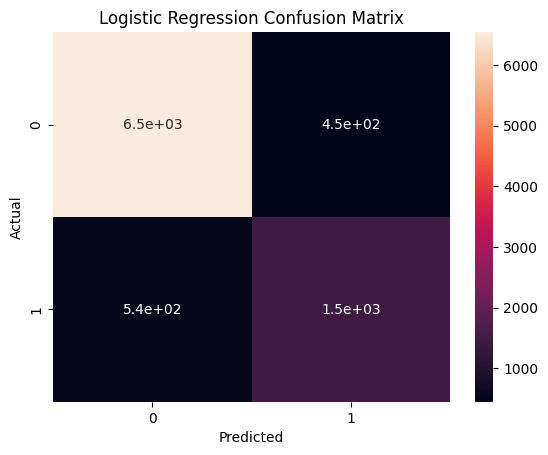

In [38]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [40]:
y_pred_svm = svm_model.predict(X_test)

y_pred_svm[:10]

array([0, 0, 1, 0, 1, 0, 0, 1, 0, 1])

In [41]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)

recall_svm = recall_score(y_test, y_pred_svm)

f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

SVM Accuracy: 0.8897777777777778
Precision: 0.768177028451001
Recall: 0.7253731343283583
F1 Score: 0.7461617195496417


In [42]:
sample_data = X_test[0].reshape(1,-1)

prediction = log_model.predict(sample_data)

print("Predicted Loan Status:", prediction[0])

Predicted Loan Status: 0


In [43]:
print("Logistic Regression Report")

print(classification_report(y_test, y_pred_log))

print("SVM Report")

print(classification_report(y_test, y_pred_svm))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000

SVM Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



In [44]:
sample_data = X_test[0].reshape(1,-1)

prediction = log_model.predict(sample_data)

print("Predicted Loan Status:", prediction[0])

Predicted Loan Status: 0


In [47]:
# Actual vs Predicted
print("Actual Loan Status:", y_test.iloc[0])

print("Predicted Loan Status:", prediction[0])

Actual Loan Status: 0
Predicted Loan Status: 0


In [49]:
# Compare Models
print("Logistic Regression Accuracy:", accuracy_log)

print("SVM Accuracy:", accuracy_svm)

Logistic Regression Accuracy: 0.8901111111111111
SVM Accuracy: 0.8897777777777778


In [51]:
# Select the first row from the test dataset
sample_data = X_test[0].reshape(1, -1)

# Predict loan approval
prediction = log_model.predict(sample_data)

# Show actual vs predicted
actual = y_test.iloc[0]
predicted = prediction[0]

print("Actual Loan Status:", actual)
print("Predicted Loan Status:", predicted)

# Loan decision message
if predicted == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Actual Loan Status: 0
Predicted Loan Status: 0
Loan Rejected


In [ ]:
models = ["Logistic Regression","SVM"]

accuracy_values = [loan_amnt, loan_int_rate]

plt.bar(models, accuracy_values)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [5]:
from sklearn.model_selection import cross_val_score

In [6]:
log_model = LogisticRegression(max_iter=1000)

scores_log = cross_val_score(log_model, X, y, cv=5)

print("Logistic Regression Cross Validation Scores:", scores_log)

NameError: name 'X' is not defined

In [13]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [14]:
print(X.shape)
print(y.shape)

(45000, 13)
(45000,)


In [15]:
log_model = LogisticRegression(max_iter=1000)

In [17]:
scores_log = cross_val_score(log_model, X, y, cv=5)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 2919, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1314, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1022, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_array_api.py", line 878, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\pandas\core\generic.py", line 2039, in __array__
    arr = np.asarray(values, dtype=dtype)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: could not convert string to float: 'male'

--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 2919, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1314, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1022, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_array_api.py", line 878, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\pandas\core\generic.py", line 2039, in __array__
    arr = np.asarray(values, dtype=dtype)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: could not convert string to float: 'female'


In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [19]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\umend\AppData\Local\Temp\ipykernel_12440\4134231849.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [20]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [21]:
print(X.shape)
print(y.shape)

(45000, 13)
(45000,)


In [22]:
log_model = LogisticRegression(max_iter=1000)

In [23]:
scores_log = cross_val_score(log_model, X, y, cv=5)

C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\umend\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

In [24]:
print("Logistic Regression Cross Validation Scores:", scores_log)

Logistic Regression Cross Validation Scores: [0.87433333 0.878      0.86944444 0.88711111 0.89033333]


In [25]:
print("Mean Accuracy:", scores_log.mean())

Mean Accuracy: 0.8798444444444444


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [28]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

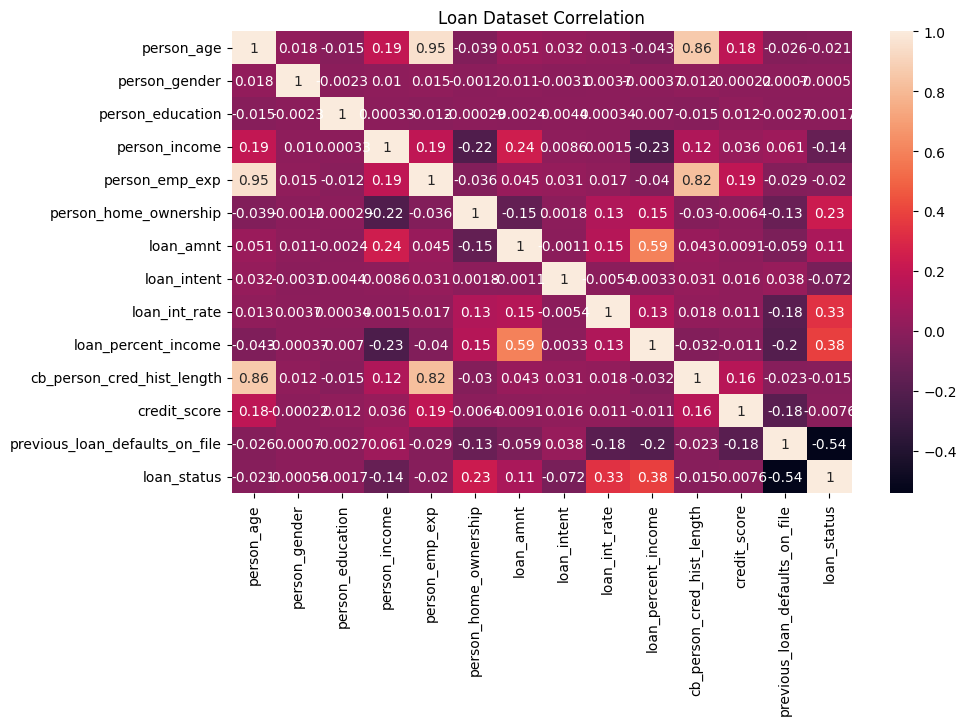

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)

plt.title("Loan Dataset Correlation")
plt.show()

In [31]:
# Feature and Target Selection
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

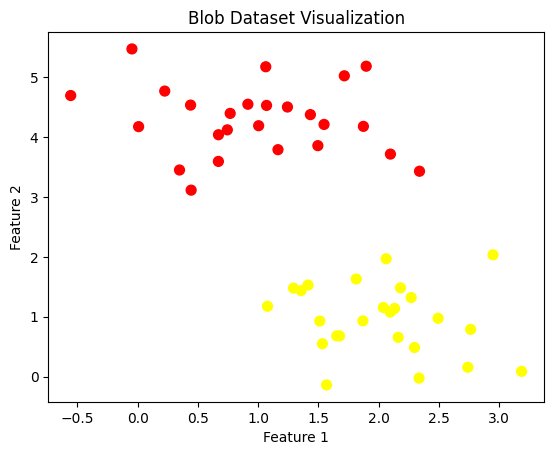

In [34]:
# Step 1: Import required libraries
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Step 2: Generate sample dataset
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)

# Step 3: Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

plt.title("Blob Dataset Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [36]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# Create loan dataset
data = {
    "Income":[20,30,40,50,60,70,80,90],
    "CreditScore":[550,600,620,650,700,720,750,780],
    "LoanApproved":[0,0,0,1,1,1,1,1]
}

df = pd.DataFrame(data)

print(df)

   Income  CreditScore  LoanApproved
0      20          550             0
1      30          600             0
2      40          620             0
3      50          650             1
4      60          700             1
5      70          720             1
6      80          750             1
7      90          780             1


In [38]:
# Features and target
X = df[["Income","CreditScore"]].values
y = df["LoanApproved"].values

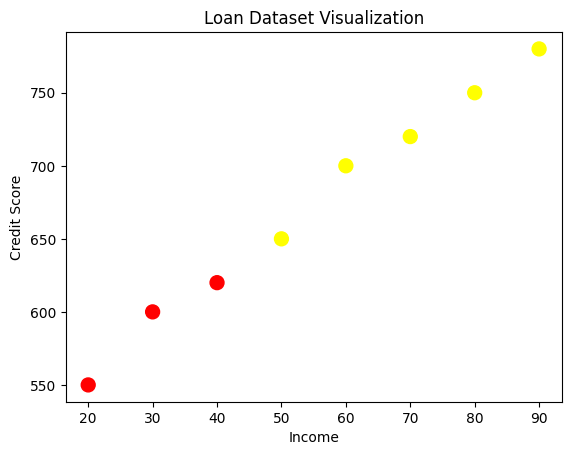

In [39]:
plt.scatter(X[:,0], X[:,1], c=y, s=100, cmap='autumn')

plt.xlabel("Income")
plt.ylabel("Credit Score")
plt.title("Loan Dataset Visualization")

plt.show()

In [40]:
xfit = np.linspace(10, 100)

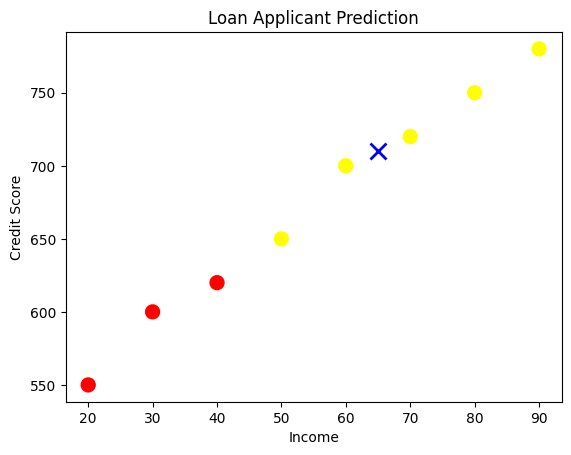

In [41]:
plt.scatter(X[:,0], X[:,1], c=y, s=100, cmap='autumn')

# New applicant
plt.plot([65], [710], 'x', color='blue', markeredgewidth=2, markersize=12)

plt.xlabel("Income")
plt.ylabel("Credit Score")
plt.title("Loan Applicant Prediction")

plt.show()

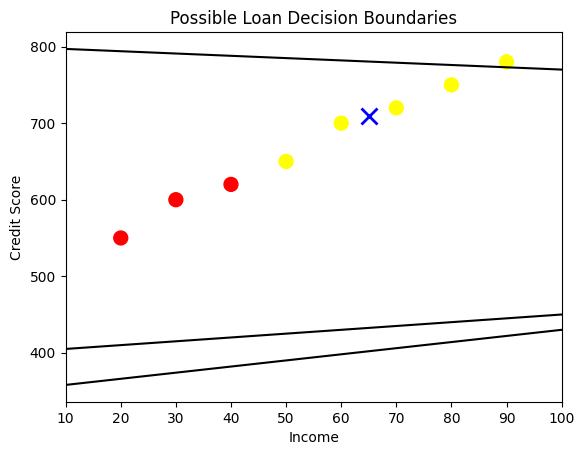

In [42]:
plt.scatter(X[:,0], X[:,1], c=y, s=100, cmap='autumn')

# New applicant
plt.plot([65], [710], 'x', color='blue', markeredgewidth=2, markersize=12)

# Possible decision lines
for m, b in [(0.5,400), (0.8,350), (-0.3,800)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(10,100)

plt.xlabel("Income")
plt.ylabel("Credit Score")
plt.title("Possible Loan Decision Boundaries")

plt.show()

(-1.0, 3.5)

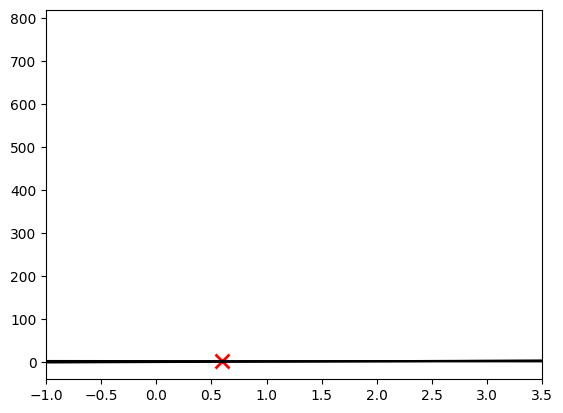

In [44]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5)

(-1.0, 3.5)

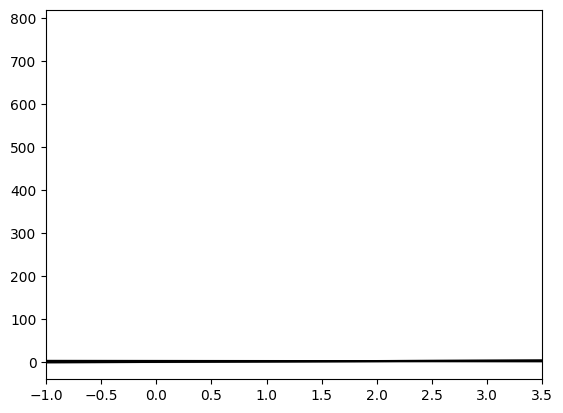

In [45]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5)

In [46]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300,marker='o', linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

NameError: name 'model' is not defined

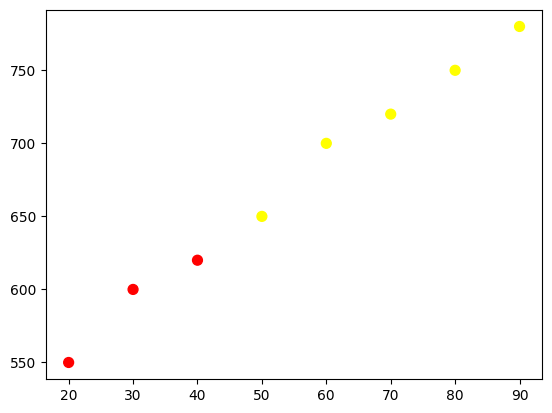

In [47]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)

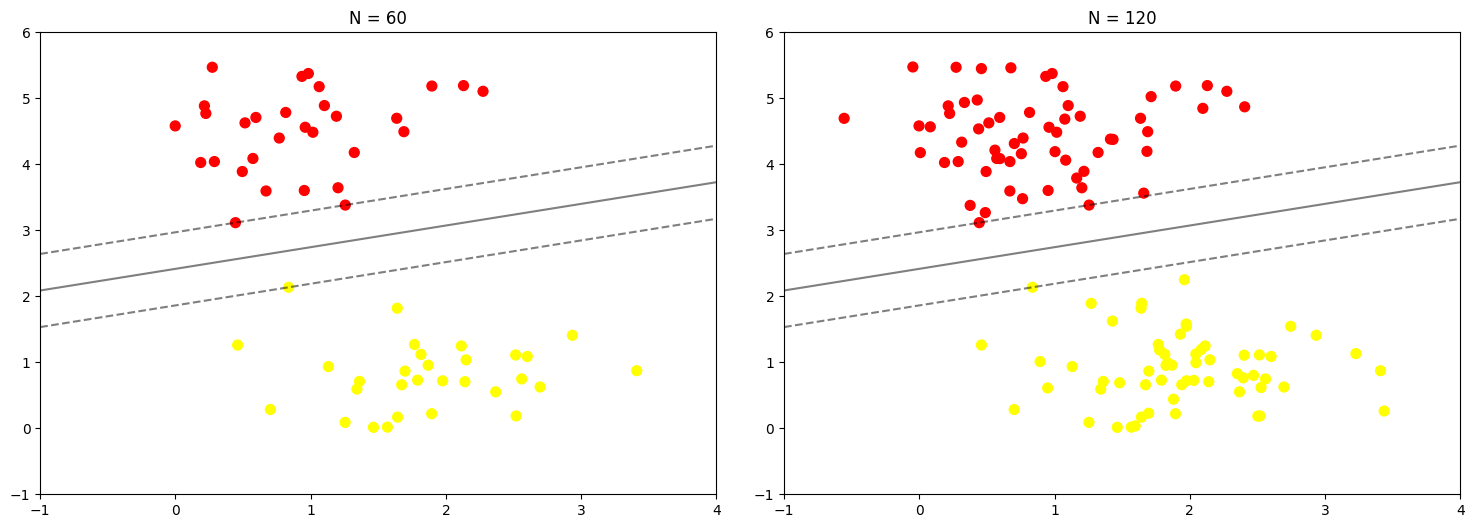

In [48]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50,marker='o', cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

In [49]:
from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None))

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

<function __main__.plot_svm(N=10, ax=None)>

In [50]:
from sklearn.datasets.samples_generator import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False)

ModuleNotFoundError: No module named 'sklearn.datasets.samples_generator'

In [52]:
from sklearn.datasets import make_circles

In [53]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.svm import SVC

In [54]:
# Create circular dataset
X, y = make_circles(n_samples=100, factor=0.1, noise=0.1)

print(X[:5])
print(y[:5])

[[-0.37898722  0.10999115]
 [ 0.04015653 -0.0778779 ]
 [ 0.13815632 -0.07916765]
 [ 1.196588   -0.37281062]
 [-0.02343725 -0.84816886]]
[1 1 1 0 0]


In [55]:
# Train SVM model
clf = SVC(kernel='linear')

clf.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


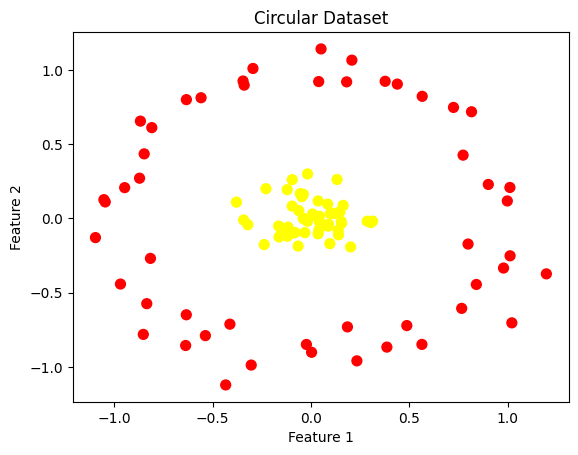

In [56]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')

plt.title("Circular Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [58]:
def plot_svc_decision_function(model):
    
    ax = plt.gca()
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    
    Y, X = np.meshgrid(y, x)
    
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1],
               alpha=0.5,
               linestyles=['--','-','--'])

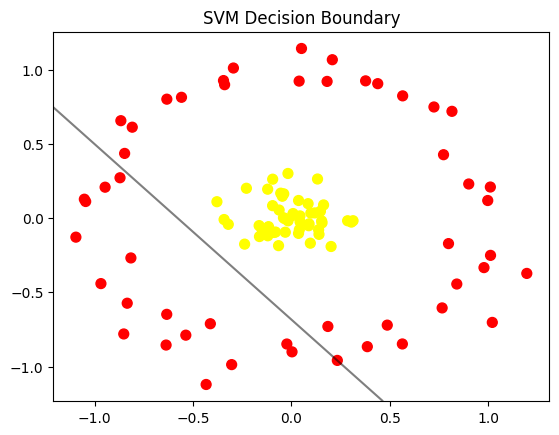

In [59]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')

plot_svc_decision_function(clf)

plt.title("SVM Decision Boundary")

plt.show()

In [61]:
X

array([[-0.37898722,  0.10999115],
       [ 0.04015653, -0.0778779 ],
       [ 0.13815632, -0.07916765],
       [ 1.196588  , -0.37281062],
       [-0.02343725, -0.84816886],
       [ 0.00616033,  0.01757734],
       [ 0.03902561,  0.92189561],
       [-0.05449107,  0.1673848 ],
       [-0.87167255,  0.27122836],
       [-0.11531675, -0.09797642],
       [ 0.04372212, -0.02497674],
       [-0.34250614, -0.00997813],
       [-0.01745246, -0.01859352],
       [-0.80948094,  0.61170994],
       [-0.55907405,  0.8129588 ],
       [-0.09589291,  0.08340593],
       [-0.85261573, -0.78042696],
       [ 0.18119721,  0.91991635],
       [-0.30401632, -0.98683996],
       [ 0.38568898, -0.86592013],
       [ 0.28559074, -0.01812911],
       [-0.8163484 , -0.26861223],
       [-0.9474948 ,  0.20771223],
       [ 0.77320949,  0.42645487],
       [ 0.03599974, -0.10330191],
       [-0.29516003,  1.01012787],
       [ 0.56392838, -0.84774139],
       [-0.96872257, -0.44135528],
       [ 0.08947807,

In [62]:
r = np.exp(-(X ** 2).sum(1))

In [63]:
np.exp(-1.216)

np.float64(0.2964134525853191)

In [64]:
r


array([0.85579076, 0.99235188, 0.97496405, 0.20787661, 0.4867816 ,
       0.99965315, 0.42681078, 0.96948823, 0.43457886, 0.97736282,
       0.99746775, 0.88922052, 0.9993499 , 0.35720393, 0.37777149,
       0.98397774, 0.26288994, 0.4151653 , 0.34428722, 0.40714998,
       0.92137263, 0.47779321, 0.39028003, 0.45853591, 0.98810406,
       0.33039124, 0.35462986, 0.32199543, 0.99050326, 0.91614868,
       0.97629706, 0.96612294, 0.40299315, 0.35276353, 0.97654799,
       0.91699602, 0.98466377, 0.30739884, 0.99876596, 0.96283514,
       0.94899666, 0.27088448, 0.33702357, 0.97510007, 0.36378623,
       0.32467004, 0.97229354, 0.98997273, 0.91148777, 0.92537127,
       0.36919989, 0.42100722, 0.99320338, 0.98359716, 0.90630852,
       0.40493274, 0.32065822, 0.38555159, 0.34315927, 0.36957588,
       0.4024216 , 0.96189693, 0.34427906, 0.98483095, 0.30659348,
       0.43940498, 0.97170281, 0.97228069, 0.97652261, 0.99791819,
       0.98922736, 0.5131459 , 0.50842235, 0.95892153, 0.23603

In [66]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, interactive, fixed, interact_manual

Text(0.5, 0, 'r')

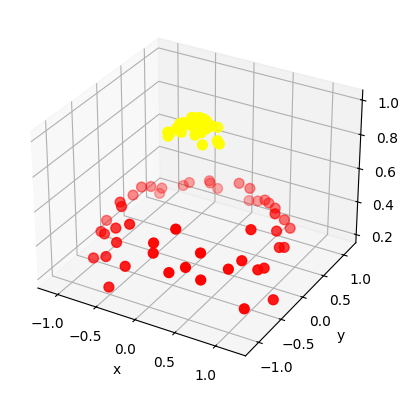

In [67]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r')

In [68]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [69]:
clf.support_vectors_

array([[ 0.03902561,  0.92189561],
       [-0.87167255,  0.27122836],
       [-0.8163484 , -0.26861223],
       [ 0.77320949,  0.42645487],
       [ 0.79849146, -0.17206528],
       [-0.41241908, -0.71158505],
       [ 0.18517584, -0.72994762],
       [-0.33983865,  0.89790718],
       [-0.37898722,  0.10999115],
       [ 0.31313676, -0.01791297],
       [ 0.20150156, -0.19155271]])

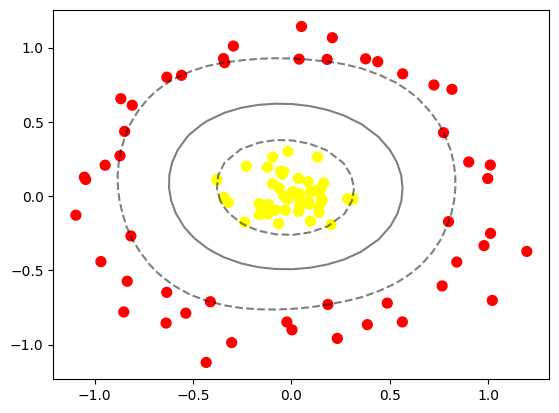

In [70]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')

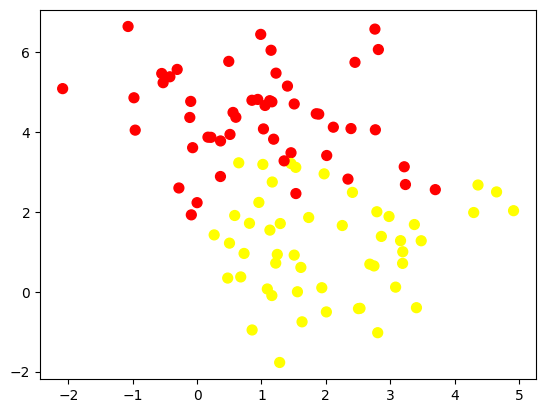

In [71]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

TypeError: plot_svc_decision_function() takes 1 positional argument but 2 were given

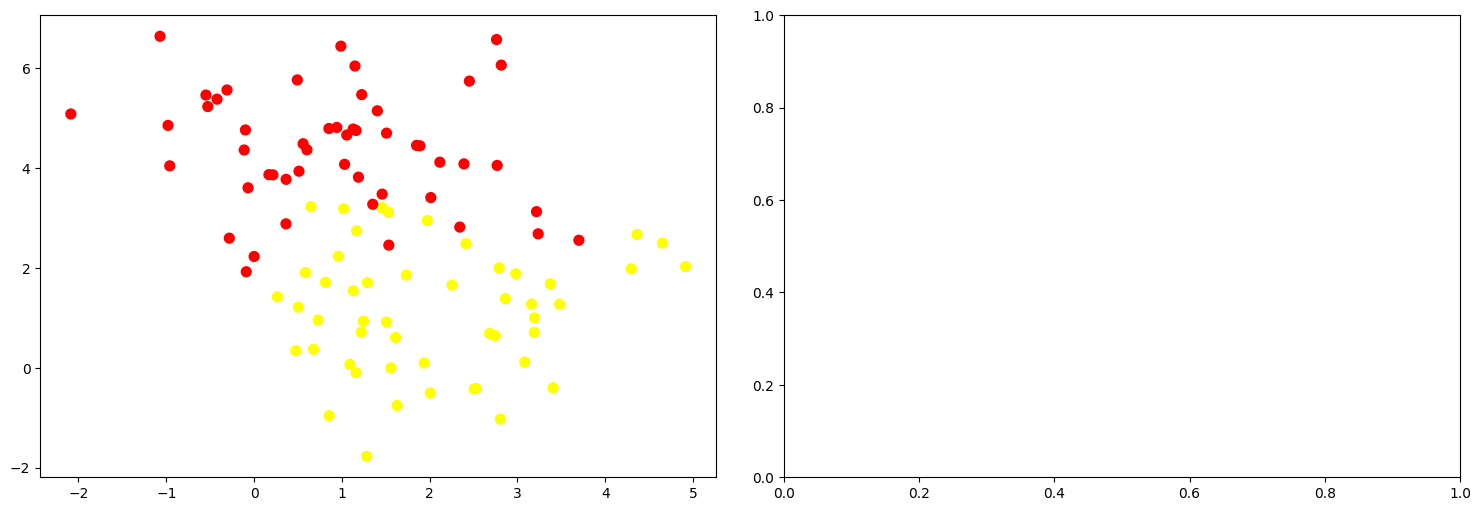

In [73]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [76]:
loan_data = {
    "Income":[25,30,35,40,45,50,55,60,65,70,75,80],
    "CreditScore":[520,540,560,580,600,620,650,670,690,720,750,780],
    "LoanApproved":[0,0,0,0,1,1,1,1,1,1,1,1]
}

df = pd.DataFrame(loan_data)

X = df[["Income","CreditScore"]].values
y = df["LoanApproved"].values

In [77]:
def plot_svc_decision_function(model, ax=None):
    
    if ax is None:
        ax = plt.gca()
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)

    Y, X = np.meshgrid(y, x)

    xy = np.vstack([X.ravel(), Y.ravel()]).T

    P = model.decision_function(xy).reshape(X.shape)

    ax.contour(X, Y, P,
               colors='k',
               levels=[-1,0,1],
               alpha=0.5,
               linestyles=['--','-','--'])

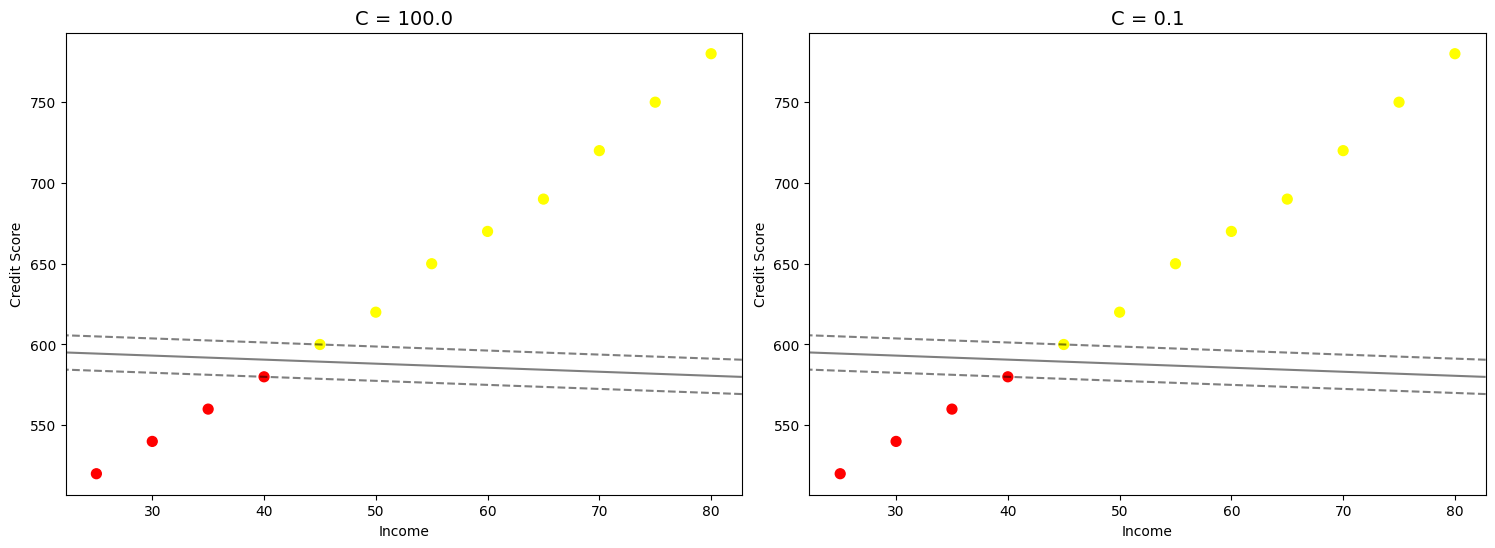

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.1]):

    model = SVC(kernel='linear', C=C).fit(X, y)

    axi.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')

    plot_svc_decision_function(model, axi)

    axi.scatter(model.support_vectors_[:,0],
                model.support_vectors_[:,1],
                s=300, lw=1,
                facecolors='none')

    axi.set_xlabel("Income")
    axi.set_ylabel("Credit Score")

    axi.set_title('C = {0:.1f}'.format(C), size=14)

plt.show()

In [79]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

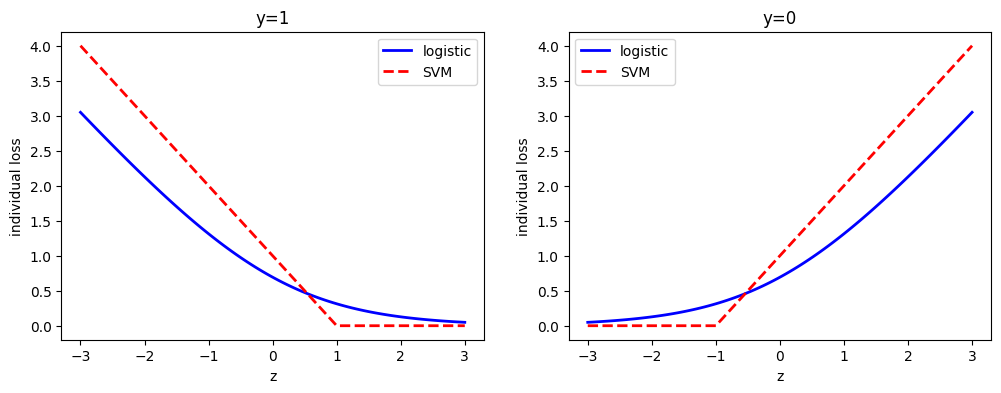

In [80]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
z = np.linspace(-3,3,num=100)
ax[0].plot(z,-np.log(sigmoid(z)),label='logistic',lw=2, color='b')
ax[1].plot(z,-np.log(1-sigmoid(z)),label='logistic',lw=2,color='b')
ax[0].plot(z,np.maximum(0,1-z),label='SVM',lw=2, color='r',linestyle='--')
ax[1].plot(z,np.maximum(0,1+z),label='SVM',lw=2,color='r',linestyle='--')
ax[0].set_title('y=1')
ax[1].set_title('y=0')
ax[0].set_xlabel('z')
ax[1].set_xlabel('z')
ax[0].set_ylabel('individual loss')
ax[1].set_ylabel('individual loss')
ax[0].legend()
ax[1].legend()
plt.show()